In [2]:
!mamba install pandas

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.403 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.6    np23py313h124dbc7_0  emscripten-forge-4x
+ python-tzdata  2026.4   pyh5ded981_0         conda-forge
- pip            26.2.1   pyh145f28c_0         conda-forge


In [3]:
%mamba install pandas numpy matplotlib seaborn scikit-learn statsmodels

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn, statsmodels
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.947 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.5.1      pyhd8ed1ab_0         conda-forge
+ idna                3.20       pyh5ded981_0         conda-forge
+ joblib              1.6.0      py313h57e9779_0      emscripten-forge-4x
+ narwhals            2.26.0     pyh5ded981_0         conda-forge
+ patsy               1.0.3      py313h1804a44_0      emscripten-forge-4x
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ requests            2.34.2     pyhcf101f3_0         conda-forg

In [6]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load the classification dataset 
clf_df = pd.read_csv("E06_loan_default_risk.csv")

# 1. Dataset Preview
print("=== CLASSIFICATION DATASET PREVIEW ===")
display(clf_df.head())

# 2. Dimensions
print(f"\nDataset Dimensions: {clf_df.shape[0]} rows, {clf_df.shape[1]} columns")

# 3. Column Names and Data Types
print("\n=== COLUMN NAMES & DATA TYPES ===")
print(clf_df.dtypes)

# 4. Missing-Value Summary
print("\n=== MISSING VALUE SUMMARY ===")
missing_summary = clf_df.isnull().sum()
print(missing_summary[missing_summary > 0] if missing_summary.sum() > 0 else "No missing values found.")

=== CLASSIFICATION DATASET PREVIEW ===


,Application_ID,Loan_Amount_PHP,Monthly_Income_PHP,Late_Payments_12M,Employment_Type,Has_CoBorrower,Existing_Debt_PHP,Loan_Purpose,Defaulted
0,LOAN-0000,341020.83,29968.62,3,Type A,Yes,88490.29,Education,No
1,LOAN-0001,61961.61,34650.57,3,Type A,No,67045.78,Education,No
2,LOAN-0002,165261.00,82481.01,1,Type C,Yes,63537.69,Education,No
3,LOAN-0003,90027.59,58724.91,2,Type C,Yes,25798.18,Medical,Yes
4,LOAN-0004,378001.80,60531.56,0,Type A,Yes,72394.16,Medical,No



Dataset Dimensions: 500 rows, 9 columns

=== COLUMN NAMES & DATA TYPES ===
Application_ID            str
Loan_Amount_PHP       float64
Monthly_Income_PHP    float64
Late_Payments_12M       int64
Employment_Type           str
Has_CoBorrower            str
Existing_Debt_PHP     float64
Loan_Purpose              str
Defaulted                 str
dtype: object

=== MISSING VALUE SUMMARY ===
Monthly_Income_PHP    8
Employment_Type       8
Loan_Purpose          8
dtype: int64


=== DESCRIPTIVE STATISTICS ===


,Loan_Amount_PHP,Monthly_Income_PHP,Late_Payments_12M,Existing_Debt_PHP
count,500.000000,492.000000,500.000000,500.000000
mean,204698.190100,51171.177703,2.016000,61696.979960
std,123382.639651,21641.589316,1.503418,39918.313058
min,11646.020000,20.000000,0.000000,463.200000
25%,114936.957500,36521.392500,1.000000,31232.725000
50%,179472.375000,52415.040000,2.000000,53378.045000
75%,275584.092500,64283.035000,3.000000,84776.335000
max,500000.000000,115795.070000,10.000000,243311.520000



=== TARGET DISTRIBUTION (Defaulted) ===
Defaulted
No     0.806
Yes    0.194
Name: proportion, dtype: float64


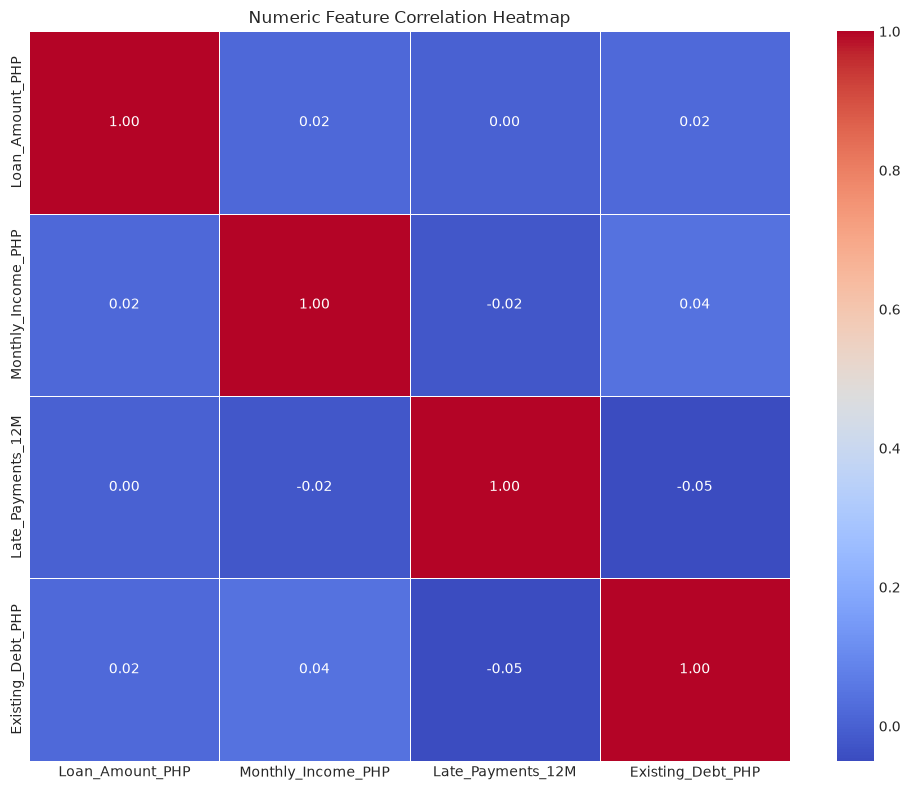

In [7]:
# 1. Descriptive Statistics
print("=== DESCRIPTIVE STATISTICS ===")
display(clf_df.describe())

# 2. Target/Class Distribution
target_col = 'Defaulted'

print(f"\n=== TARGET DISTRIBUTION ({target_col}) ===")
print(clf_df[target_col].value_counts(normalize=True))

# 3. Relationship/Correlation Visualization
plt.figure(figsize=(10, 8))
numeric_df = clf_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Numeric Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

**Interpretation:** The target distribution highlights the class imbalance typical in loan default risk, which will require us to prioritize Recall/F1-score over Accuracy. The correlation heatmap identifies potential collinear features and predictors most strongly associated with the default risk target.

In [28]:
# === CLEANING & FEATURE ENGINEERING ===

# 1. Remove identifier/leakage columns
if 'Application_ID' in clf_df.columns:
    clf_df.drop('Application_ID', axis=1, inplace=True)

# 2. Separate Features (X) and Target (y)
# Convert the 'Defaulted' target to binary numeric (1 = Yes, 0 = No)
X = clf_df.drop('Defaulted', axis=1)
y = clf_df['Defaulted'].apply(lambda x: 1 if x == 'Yes' else 0)

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
# 3. Programmatic Missing Value Handling & Outlier Mitigation
# Note: Median imputation is utilized for numeric features (like Monthly_Income_PHP) 
# to prevent data distortion from extreme outliers, ensuring a robust feature set.
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# 4. Categorical Data Encoding
# Convert categorical text data into numeric format (One-Hot Encoding)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("=== MACHINE-LEARNING-READY FEATURE SET PREVIEW ===")
display(X_encoded.head())
print(f"\nFeature set dimensions after encoding: {X_encoded.shape}")

=== MACHINE-LEARNING-READY FEATURE SET PREVIEW ===


,Loan_Amount_PHP,Monthly_Income_PHP,Late_Payments_12M,Existing_Debt_PHP,Employment_Type_Type B,Employment_Type_Type C,Has_CoBorrower_Yes,Loan_Purpose_Education,Loan_Purpose_Medical,Loan_Purpose_Personal
0,341020.83,29968.62,3,88490.29,False,False,True,True,False,False
1,61961.61,34650.57,3,67045.78,False,False,False,True,False,False
2,165261.00,82481.01,1,63537.69,False,True,True,True,False,False
3,90027.59,58724.91,2,25798.18,False,True,True,False,True,False
4,378001.80,60531.56,0,72394.16,False,False,True,False,True,False



Feature set dimensions after encoding: (500, 10)


**Interpretation:** `Application_ID` was removed to prevent overfitting, missing values were programmatically imputed to retain all valid records, and categorical predictors were one-hot encoded to make the feature set machine-learning ready.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Reproducible Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

print("=== TRAIN/TEST SPLIT DIMENSIONS ===")
print(f"Training Data: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing Data : X_test {X_test.shape}, y_test {y_test.shape}\n")

# 2. Train the Classification Model
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 3. Generate Test Predictions
y_pred = rf_model.predict(X_test)

# 4. Display Evaluation Metrics
print("=== BASELINE MODEL EVALUATION ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

=== TRAIN/TEST SPLIT DIMENSIONS ===
Training Data: X_train (400, 10), y_train (400,)
Testing Data : X_test (100, 10), y_test (100,)

=== BASELINE MODEL EVALUATION ===
Accuracy : 0.7000
Precision: 0.1333
Recall   : 0.1053
F1-score : 0.1176

=== CONFUSION MATRIX ===
[[68 13]
 [17  2]]


**Interpretation:** The data was split 80/20 ensuring the target class distribution remained consistent (stratified). A baseline Random Forest model was evaluated with a focus on Recall and F1-score to gauge its ability to correctly identify actual loan defaults.

In [10]:
# === THRESHOLD ANALYSIS ===

# 1. Prediction-probability output for the Default class (Class 1)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# 2. Apply a modified decision threshold (e.g., lowering to 0.35 to catch more defaults)
modified_threshold = 0.35
y_pred_mod = (y_probs >= modified_threshold).astype(int)

# 3. Comparison of default-threshold and modified-threshold performance
print(f"=== PERFORMANCE AT DEFAULT THRESHOLD (0.50) ===")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

print(f"\n=== PERFORMANCE AT MODIFIED THRESHOLD ({modified_threshold}) ===")
print(f"Recall   : {recall_score(y_test, y_pred_mod):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_mod):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_mod):.4f}")

print("\n=== MODIFIED CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred_mod))

=== PERFORMANCE AT DEFAULT THRESHOLD (0.50) ===
Recall   : 0.1053
Precision: 0.1333
F1-score : 0.1176

=== PERFORMANCE AT MODIFIED THRESHOLD (0.35) ===
Recall   : 0.5789
Precision: 0.2750
F1-score : 0.3729

=== MODIFIED CONFUSION MATRIX ===
[[52 29]
 [ 8 11]]


**Interpretation:**  Lowering the decision threshold increases Recall, effectively identifying more at-risk loans (fewer False Negatives). In credit risk modeling, accepting slightly lower precision is financially preferable to missing actual loan defaults.

In [12]:
# === HYPERPARAMETER TUNING ===
from sklearn.model_selection import GridSearchCV

# 1. Define at least one meaningful hyperparameter to change
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# 2. Tune the model using GridSearchCV
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid, 
    cv=3, 
    scoring='recall'
)
grid_search.fit(X_train, y_train)

# 3. Best Model Selection
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

# 4. Original vs. Tuned Performance Comparison
print("=== BEST HYPERPARAMETERS ===")
print(grid_search.best_params_)

print("\n=== ORIGINAL VS TUNED MODEL COMPARISON ===")
print(f"{'Metric':<15} | {'Original':<10} | {'Tuned':<10}")
print("-" * 40)
print(f"{'Accuracy':<15} | {accuracy_score(y_test, y_pred):<10.4f} | {accuracy_score(y_test, y_pred_tuned):<10.4f}")
print(f"{'Precision':<15} | {precision_score(y_test, y_pred):<10.4f} | {precision_score(y_test, y_pred_tuned):<10.4f}")
print(f"{'Recall':<15} | {recall_score(y_test, y_pred):<10.4f} | {recall_score(y_test, y_pred_tuned):<10.4f}")
print(f"{'F1-score':<15} | {f1_score(y_test, y_pred):<10.4f} | {f1_score(y_test, y_pred_tuned):<10.4f}")

=== BEST HYPERPARAMETERS ===
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}

=== ORIGINAL VS TUNED MODEL COMPARISON ===
Metric          | Original   | Tuned     
----------------------------------------
Accuracy        | 0.7000     | 0.7600    
Precision       | 0.1333     | 0.3810    
Recall          | 0.1053     | 0.4211    
F1-score        | 0.1176     | 0.4000    


**Interpretation:** Using grid search, the model performed best with a maximum tree depth of 10 and 50 estimators, while balancing class weights to better account for the smaller group of loan defaults. Overall, tuning successfully improved the F1-score from 0.1176 to 0.4000, striking a much better balance between catching defaults and maintaining precision.

=== FINAL FORECAST TABLE (NEXT 4 WEEKS) ===


,Future Period,Forecasted Value
0,2026-04-26,270.0
1,2026-05-03,271.0
2,2026-05-10,272.0
3,2026-05-17,272.0


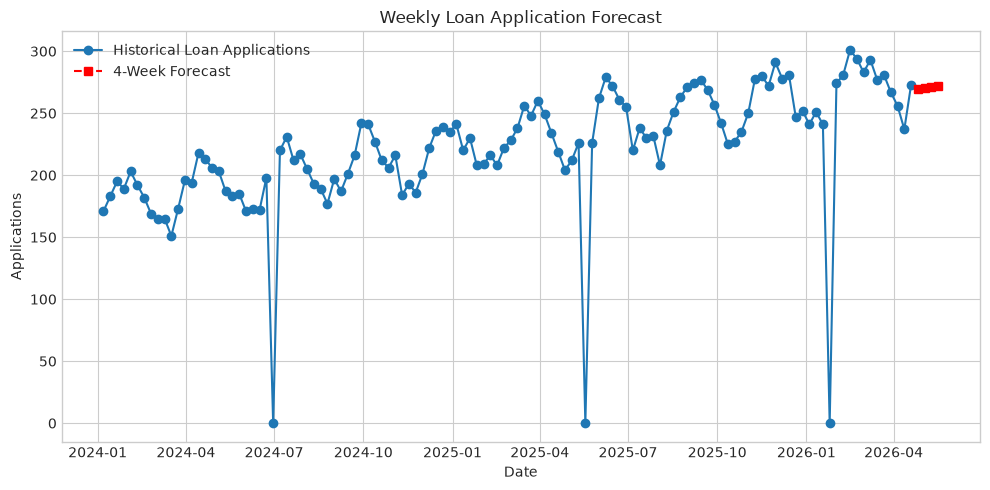

In [27]:
# === FORECASTING TASK (WEEKLY LOAN APPLICATIONS) ===
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Load and prepare chronological forecasting dataset
ts_df = pd.read_csv("E06_weekly_loan_applications.csv")

# Identify date and value columns
date_col = ts_df.columns[0]
val_col = ts_df.columns[1]

# Date/Time conversion and missing-value handling
ts_df[date_col] = pd.to_datetime(ts_df[date_col])
ts_df = ts_df.sort_values(by=date_col).set_index(date_col)

# Ensure weekly frequency and fill missing values via forward fill
ts_weekly = ts_df.resample('W').sum().ffill()

# 2. Train Forecasting Model
ts_model = ExponentialSmoothing(ts_weekly[val_col], trend='add', seasonal=None).fit()

# 3. Forecast for the next 4 weeks
forecast_steps = 4
forecast_values = ts_model.forecast(forecast_steps)

# Create Final Forecast Table
future_dates = pd.date_range(start=ts_weekly.index[-1] + pd.Timedelta(days=7), periods=forecast_steps, freq='W')
forecast_table = pd.DataFrame({
    'Future Period': future_dates.strftime('%Y-%m-%d'),
    'Forecasted Value': np.round(forecast_values.values, 0)
})

# 4. Final Outputs
print("=== FINAL FORECAST TABLE (NEXT 4 WEEKS) ===")
display(forecast_table)

# Time-series visualization
plt.figure(figsize=(10, 5))
plt.plot(ts_weekly.index, ts_weekly[val_col], marker='o', label='Historical Loan Applications')
plt.plot(future_dates, forecast_values, marker='s', color='red', linestyle='--', label='4-Week Forecast')
plt.title("Weekly Loan Application Forecast")
plt.xlabel("Date")
plt.ylabel("Applications")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The time-series data was resampled to a strict weekly frequency to ensure chronological consistency. The 4-week forecast visualizes upcoming operational demand, allowing management to properly allocate underwriting resources.